In [1]:
import boto3
import botocore
from iterdub import iterdub as ib
from matplotlib import pyplot as plt
import pandas as pd
from pandas.util import hash_pandas_object
import seaborn as sns
from teeplot import teeplot as tp


In [2]:
from dishpylib.pyhelpers import make_outattr_metadata
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmec1zy
interpreter: 3.10.12 (main, Jun 22 2026, 18:55:27) [GCC 11.4.0]
notebook name: bucket=prq49--a=all_stints_all_thread_profiles+endeavor=16--phylogenetic_roots
notebook path: /home/runner/work/oee4/oee4/binder/bucket=prq49--a=all_stints_all_thread_profiles+endeavor=16--phylogenetic_roots.ipynb
revision: bdac574
timestamp: 2026-08-26T01:31:55Z00:00

IPython==7.16.1
packaging==26.2


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


# get data


In [4]:
s3_handle = boto3.resource(
    's3',
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket('prq49')

series_profiles, = bucket_handle.objects.filter(
    Prefix=f'endeavor=16/thread-profiles/stage=8+what=elaborated/',
)


In [5]:
df = pd.read_csv(
    f's3://prq49/{series_profiles.key}',
    compression='xz',
)
dfdigest = '{:x}'.format(hash_pandas_object( df ).sum())
dfdigest


'5766f00a6933dc89'

In [6]:
for stint in df['Stint'].unique():
    exec(f'df{stint} = df[ df["Stint"] == {stint} ]')


# unique phylogenetic roots over evolutionary time


<ipython-input-7-dfa13308b567>:23: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),
<ipython-input-7-dfa13308b567>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


teeplots/bucket=prq49+ci=sd+endeavor=16+hue=series+transform=identity+viz=logx-lineplot+x=stint+y=number-phylogenetic-roots+ext=.pdf
teeplots/bucket=prq49+ci=sd+endeavor=16+hue=series+transform=identity+viz=logx-lineplot+x=stint+y=number-phylogenetic-roots+ext=.png


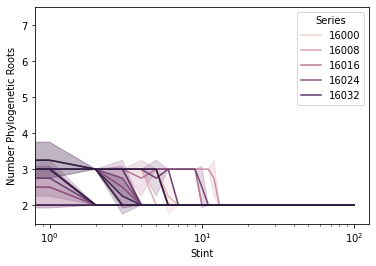

In [7]:
def logx_lineplot(*args, **kwargs):
    sns.lineplot(
        *args,
        **kwargs,
    )
    plt.gca().set_xscale('log')


tp.tee(
    logx_lineplot,
    data=df,
    x='Stint',
    y='Number Phylogenetic Roots',
    hue='Series',
    ci='sd',
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'identity',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)


# within-stint phylogenetic roots over evolutionary time


teeplots/viz=lineplot+x=stint+y=number-stint-phylogenetic-roots+ext=.pdf
teeplots/viz=lineplot+x=stint+y=number-stint-phylogenetic-roots+ext=.png


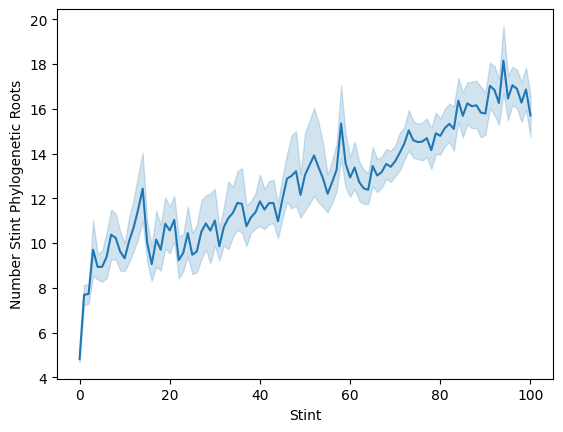

<AxesSubplot:xlabel='Stint', ylabel='Number Stint Phylogenetic Roots'>

In [8]:
tp.tee(
    sns.lineplot,
    data=df,
    x='Stint',
    y='Number Stint Phylogenetic Roots',
)


<ipython-input-9-f36450c205ca>:16: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:227: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  teed = plotter(*args, **{k: v for k, v in kwargs.items()})


teeplots/bucket=prq49+ci=sd+endeavor=16+hue=series+transform=identity+viz=lineplot+x=stint+y=number-stint-phylogenetic-roots+ext=.pdf
teeplots/bucket=prq49+ci=sd+endeavor=16+hue=series+transform=identity+viz=lineplot+x=stint+y=number-stint-phylogenetic-roots+ext=.png


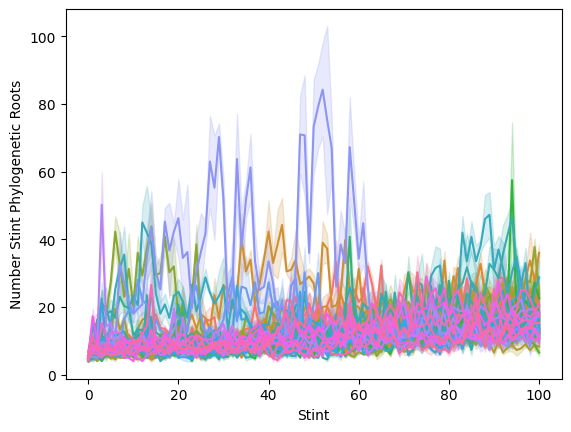

<AxesSubplot:xlabel='Stint', ylabel='Number Stint Phylogenetic Roots'>

In [9]:
tp.tee(
    sns.lineplot,
    data=df.astype({'Series': 'str'}),
    x='Stint',
    y='Number Stint Phylogenetic Roots',
    hue='Series',
    ci='sd',
    legend=False,
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'identity',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)


# explanatory factor: updates elapsed per stint


<ipython-input-10-794145da169b>:13: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),


teeplots/bucket=prq49+endeavor=16+transform=identity+viz=scatterplot+x=update+y=number-stint-phylogenetic-roots+ext=.pdf
teeplots/bucket=prq49+endeavor=16+transform=identity+viz=scatterplot+x=update+y=number-stint-phylogenetic-roots+ext=.png


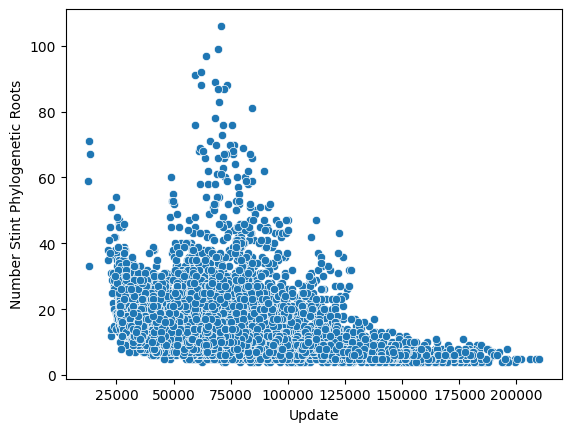

<AxesSubplot:xlabel='Update', ylabel='Number Stint Phylogenetic Roots'>

In [10]:
tp.tee(
    sns.scatterplot,
    data=df,
    x='Update',
    y='Number Stint Phylogenetic Roots',
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'identity',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)


<ipython-input-11-58f529afe1db>:15: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),


teeplots/bucket=prq49+endeavor=16+hue=series+transform=identity+viz=scatterplot+x=update+y=number-stint-phylogenetic-roots+ext=.pdf
teeplots/bucket=prq49+endeavor=16+hue=series+transform=identity+viz=scatterplot+x=update+y=number-stint-phylogenetic-roots+ext=.png


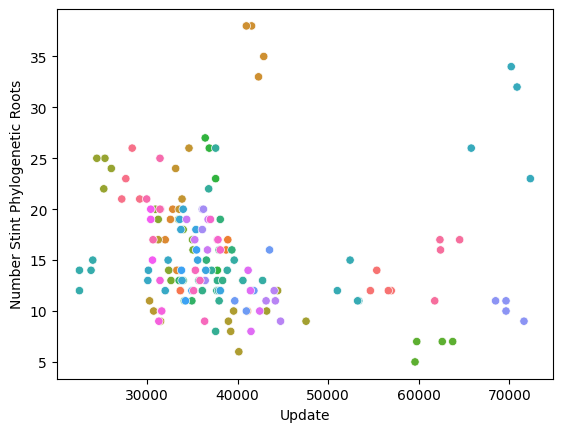

<AxesSubplot:xlabel='Update', ylabel='Number Stint Phylogenetic Roots'>

In [11]:
tp.tee(
    sns.scatterplot,
    data=df100.astype({'Series': 'str'}),
    x='Update',
    y='Number Stint Phylogenetic Roots',
    hue='Series',
    legend=False,
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'identity',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)


# explanatory factor: elapsed generations


<ipython-input-12-b2606895c6c9>:15: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),


teeplots/bucket=prq49+endeavor=16+hue=series+transform=identity+viz=scatterplot+x=elapsed-generations+y=number-stint-phylogenetic-roots+ext=.pdf
teeplots/bucket=prq49+endeavor=16+hue=series+transform=identity+viz=scatterplot+x=elapsed-generations+y=number-stint-phylogenetic-roots+ext=.png


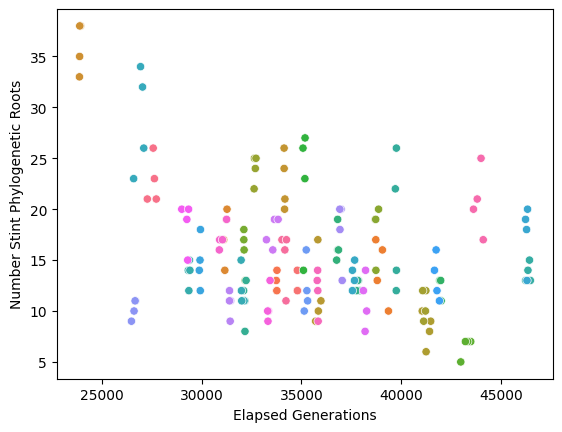

<AxesSubplot:xlabel='Elapsed Generations', ylabel='Number Stint Phylogenetic Roots'>

In [12]:
tp.tee(
    sns.scatterplot,
    data=df100.astype({'Series': 'str'}),
    x='Elapsed Generations',
    y='Number Stint Phylogenetic Roots',
    hue='Series',
    legend=False,
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'identity',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)


<ipython-input-13-074a0a328568>:13: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),


teeplots/bucket=prq49+endeavor=16+transform=identity+viz=lineplot+x=stint+y=elapsed-generations-delta+ext=.pdf
teeplots/bucket=prq49+endeavor=16+transform=identity+viz=lineplot+x=stint+y=elapsed-generations-delta+ext=.png


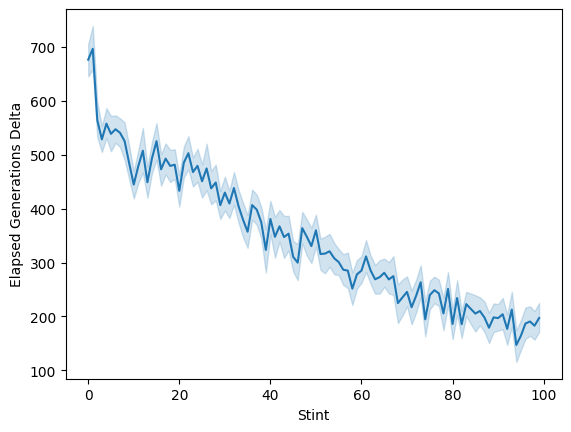

<AxesSubplot:xlabel='Stint', ylabel='Elapsed Generations Delta'>

In [13]:
tp.tee(
    sns.lineplot,
    data=df,
    x='Stint',
    y='Elapsed Generations Delta',
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'identity',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)


<ipython-input-14-5b7835393ce3>:35: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),


teeplots/bucket=prq49+endeavor=16+transform=identity+viz=dual-lineplot+x=stint+y1=elapsed-generations-delta+y2=update+ext=.pdf
teeplots/bucket=prq49+endeavor=16+transform=identity+viz=dual-lineplot+x=stint+y1=elapsed-generations-delta+y2=update+ext=.png


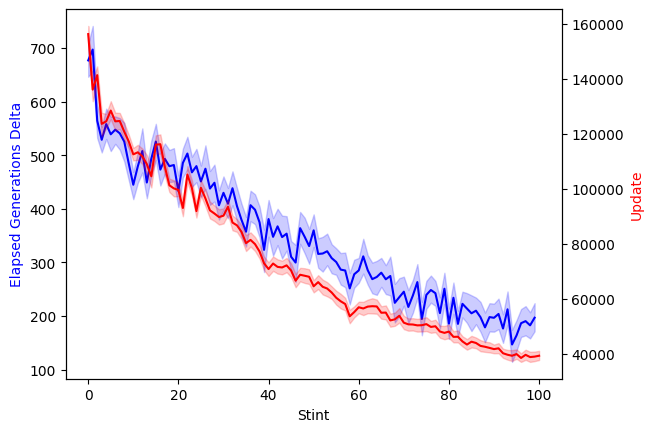

In [14]:
def dual_lineplot(*, data, x, y1, y2):

    sns.lineplot(
        data=data,
        x=x,
        y=y1,
        color='blue',
    )
    plt.gca().yaxis.label.set_color('blue')


    sns.lineplot(
        data=data,
        x=x,
        y=y2,
        ax=plt.gca().twinx(),
        color='red',
    )
    plt.gca().yaxis.label.set_color('red')


tp.tee(
    dual_lineplot,
    data=df,
    x='Stint',
    y1='Elapsed Generations Delta',
    y2='Update',
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'identity',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)


<ipython-input-15-f84c085fb474>:32: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),


teeplots/bucket=prq49+endeavor=16+transform=identity+viz=dual-lineplot+x=stint+y1=number-stint-phylogenetic-roots+y2=elapsed-generations-delta+ext=.pdf
teeplots/bucket=prq49+endeavor=16+transform=identity+viz=dual-lineplot+x=stint+y1=number-stint-phylogenetic-roots+y2=elapsed-generations-delta+ext=.png


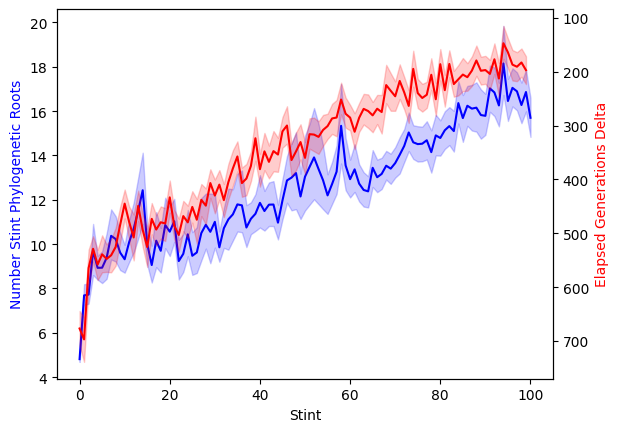

In [15]:
def dual_lineplot(*, y1, y2, **kwargs):

    sns.lineplot(
        **kwargs,
        y=y1,
        color='blue',
    )
    plt.gca().yaxis.label.set_color('blue')

    sns.lineplot(
        **kwargs,
        y=y2,
        ax=plt.gca().twinx().invert_yaxis(),
        color='red',
    )
    plt.gca().yaxis.label.set_color('red')


tp.tee(
    dual_lineplot,
    data=df,
    x='Stint',
    y1='Number Stint Phylogenetic Roots',
    y2='Elapsed Generations Delta',
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'identity',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)


<ipython-input-16-4ec27ba1607f>:13: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),


teeplots/bucket=prq49+endeavor=16+transform=identity+viz=lineplot+x=stint+y=generations-per-update+ext=.pdf
teeplots/bucket=prq49+endeavor=16+transform=identity+viz=lineplot+x=stint+y=generations-per-update+ext=.png


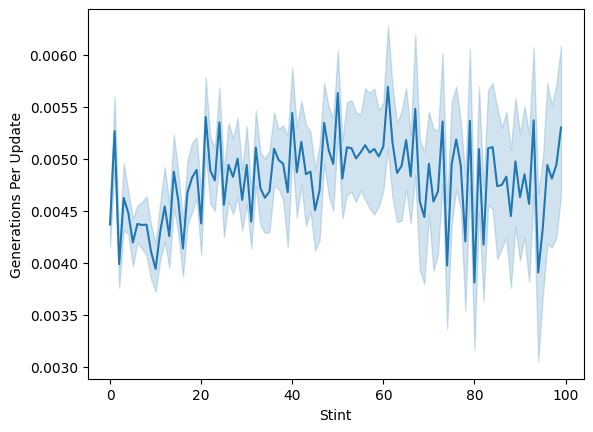

<AxesSubplot:xlabel='Stint', ylabel='Generations Per Update'>

In [16]:
tp.tee(
    sns.lineplot,
    data=df,
    x='Stint',
    y='Generations Per Update',
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'identity',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)


# case study: series 16005


<ipython-input-17-91a2d52fa9ee>:13: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),


teeplots/bucket=prq49+endeavor=16+transform=identity+viz=lineplot+x=stint+y=number-stint-phylogenetic-roots+ext=.pdf
teeplots/bucket=prq49+endeavor=16+transform=identity+viz=lineplot+x=stint+y=number-stint-phylogenetic-roots+ext=.png


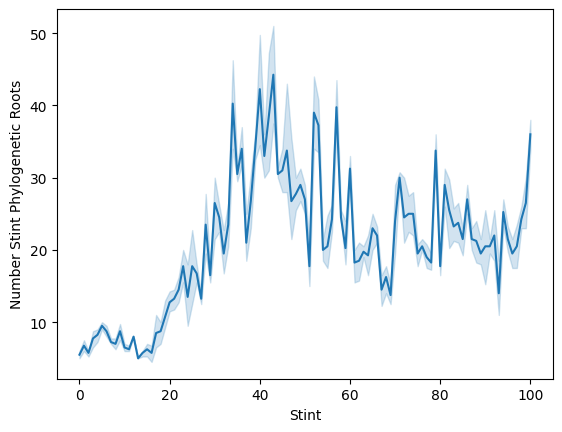

<AxesSubplot:xlabel='Stint', ylabel='Number Stint Phylogenetic Roots'>

In [17]:
tp.tee(
    sns.lineplot,
    data=df[ df['Series'] == 16005 ],
    x='Stint',
    y='Number Stint Phylogenetic Roots',
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'identity',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)


<ipython-input-18-840e8742252e>:14: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),


teeplots/bucket=prq49+endeavor=16+hue=thread+transform=identity+viz=lineplot+x=stint+y=number-stint-phylogenetic-roots+ext=.pdf
teeplots/bucket=prq49+endeavor=16+hue=thread+transform=identity+viz=lineplot+x=stint+y=number-stint-phylogenetic-roots+ext=.png


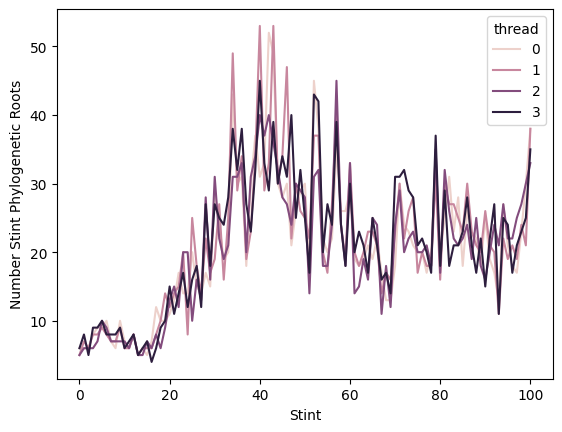

<AxesSubplot:xlabel='Stint', ylabel='Number Stint Phylogenetic Roots'>

In [18]:
tp.tee(
    sns.lineplot,
    data=df[ df['Series'] == 16005 ],
    x='Stint',
    y='Number Stint Phylogenetic Roots',
    hue='thread',
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'identity',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)


<ipython-input-19-c6fcd9bd7787>:21: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),


teeplots/bucket=prq49+endeavor=16+transform=identity+viz=logx-lineplot+x=stint+y=number-phylogenetic-roots+ext=.pdf
teeplots/bucket=prq49+endeavor=16+transform=identity+viz=logx-lineplot+x=stint+y=number-phylogenetic-roots+ext=.png


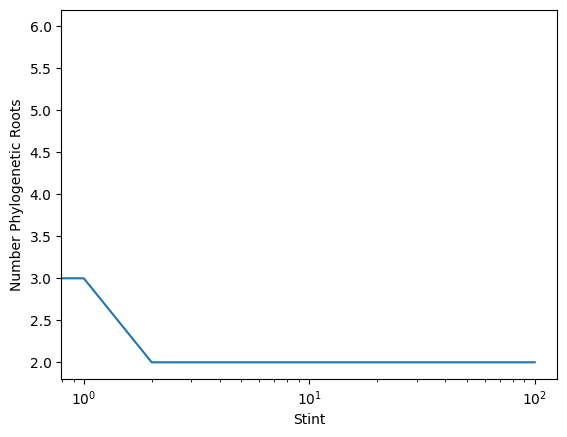

In [19]:
def logx_lineplot(*args, **kwargs):
    sns.lineplot(
        *args,
        **kwargs,
    )
    plt.gca().set_xscale('log')


tp.tee(
    logx_lineplot,
    data=df[ df['Series'] == 16005 ],
    x='Stint',
    y='Number Phylogenetic Roots',
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'identity',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)


<ipython-input-20-955ee26dd0cb>:13: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),


teeplots/bucket=prq49+endeavor=16+transform=identity+viz=lineplot+x=stint+y=update+ext=.pdf
teeplots/bucket=prq49+endeavor=16+transform=identity+viz=lineplot+x=stint+y=update+ext=.png


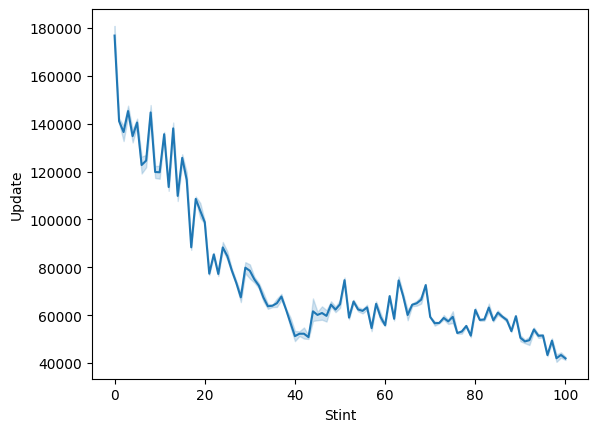

<AxesSubplot:xlabel='Stint', ylabel='Update'>

In [20]:
tp.tee(
    sns.lineplot,
    data=df[ df['Series'] == 16005 ],
    x='Stint',
    y='Update',
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'identity',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)


<ipython-input-21-79ba1961da99>:13: DeprecatedWarning: make_outattr_metadata is deprecated. use nbmetalog package instead
  **make_outattr_metadata(),
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/bucket=prq49+endeavor=16+transform=identity+viz=lineplot+x=stint+y=elapsed-generations-delta+ext=.pdf, overwriting it
  warnings.warn(


teeplots/bucket=prq49+endeavor=16+transform=identity+viz=lineplot+x=stint+y=elapsed-generations-delta+ext=.pdf


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/bucket=prq49+endeavor=16+transform=identity+viz=lineplot+x=stint+y=elapsed-generations-delta+ext=.png, overwriting it
  warnings.warn(


teeplots/bucket=prq49+endeavor=16+transform=identity+viz=lineplot+x=stint+y=elapsed-generations-delta+ext=.png


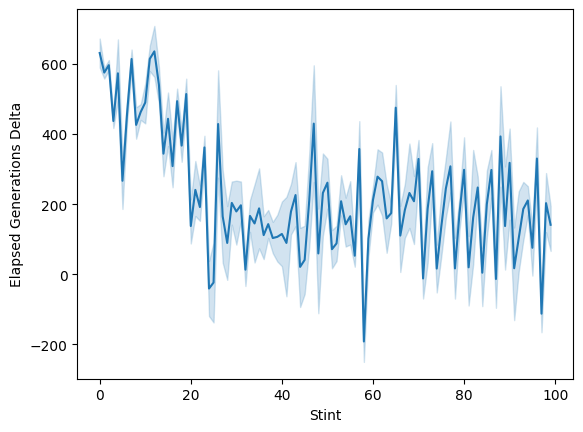

<AxesSubplot:xlabel='Stint', ylabel='Elapsed Generations Delta'>

In [21]:
tp.tee(
    sns.lineplot,
    data=df[ df['Series'] == 16005 ],
    x='Stint',
    y='Elapsed Generations Delta',
    teeplot_outattrs={
        **{
            'bucket' : ib.dub( df['Bucket'] ),
            'endeavor' : ib.dub( df['Endeavor'].astype(int) ),
            'transform' : 'identity',
            '_dfdigest' : dfdigest,
        },
        **make_outattr_metadata(),
    },
)
